In [15]:
import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

os.environ["MUJOCO_GL"] = "egl"
size=(64,64)

env =  suite.make(
                "Stack",
                robots="Panda",  # use Sawyer robot
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names="agentview",
                camera_depths=True,
                camera_segmentations="element",
                camera_heights= size[0],  # image height
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/elephant/miniconda3/envs/urlb/lib/python3.8/site-packages/robosuite-1.4.0-py3.8.egg/robosuite/scripts/setup_macros.py (__init__.py:9)


In [13]:
from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM
import custom_robosuite_tasks

class env():
    def __init__(self, task):
        self.task = task
        self.camera = "agentview"
        self.size = (64, 64)
        self.segmentation_level = "element" 
        self.horizon = 250
        self.cube_rgba = (0, 1, 0, 1)
        self.cube_minsize = (0.05, 0.05, 0.05)

    def make(self):
        self._env = custom_robosuite_tasks.make(self.task, self)

        
robot = env("Lift")

robot.make()

# cam_mover = CM(robot._env, camera=robot.camera)
# (
#     start_cam_pos,
#     start_cam_quat,
# ) = cam_mover.get_camera_pose()

# start_cam_pos += [0.2, 0.0, 0.4]

# cam_mover.set_camera_pose(pos=start_cam_pos)

In [103]:

from custom_robosuite_tasks.custom_lift import CustomLift

import os
import robosuite as suite
from robosuite.wrappers import Wrapper
import robosuite.utils.camera_utils as CU
from robosuite.utils.camera_utils import CameraMover as CM

# from custom_robosuite_tasks import *

os.environ["MUJOCO_GL"] = "egl"
camera = "sideview"
size=(256,256)

env = CustomLift(
                robots="Panda",  # use Sawyer robot
                has_renderer=False,  # on-screen renderer
                has_offscreen_renderer=True,  # off-screen rendering needed for image obs
                use_object_obs=True,  # provide object observations to agent
                use_camera_obs=True,  # provide image observations to agent
                camera_names=camera,
                camera_depths=True,
                # render_visual_mesh=False,
                cube_minsize=(0.04, 0.04, 0.04),
                camera_segmentations="element",
                camera_heights= size[0],  # image h|eight
                camera_widths= size[1],  # image width
                horizon=250,  # each episode terminates after 200 steps
                reward_shaping=True,
                control_freq=20,  # control should happen fast enough so that simulation looks smooth
            )


In [104]:
# move camera to agentview2 

cam_mover = CM(env, camera=camera)
(start_cam_pos, start_cam_quat) = cam_mover.get_camera_pose()
start_cam_pos -= [0.0, 0.0, 0.5]

cam_mover.set_camera_pose(pos=start_cam_pos)

In [106]:
action = [0,0,0,0,0,0,0,0]
env_state, rew, done, info = env.step(action)

init_qpos = [-0.3, 0.85, 0, -2.2, 0, 3, 0.75]
env.robots[0].set_robot_joint_positions(init_qpos)
env.robots[0].controller.update_initial_joints(init_qpos)
env.robots[0].controller.reset_goal()

env_state = env._get_observations(force_update=True)

def state_extraction(camera, env_state):

        rgb = env_state[camera + "_image"][::-1].transpose(2, 0, 1)
        depth = env_state[camera + "_depth"][::-1].transpose(2, 0, 1)

        # obtain world coordinates from the segmentation mask
        # depth_map = CU.get_real_depth_map(sim=self._env.sim, depth_map=depth)

        seg = env_state[
            camera + "_segmentation_" + "element"
        ][::-1].transpose(2, 0, 1)

        return  rgb, depth, seg

(3, 256, 256)


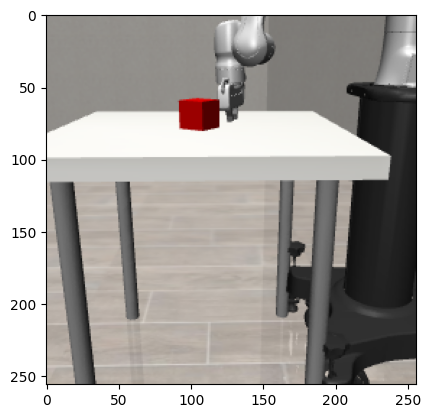

In [107]:
import matplotlib.pyplot as plt

rgb, depth, seg = state_extraction(camera, env_state)

print(rgb.shape)
plt.imshow(rgb.transpose(1,2,0))

In [7]:
# move robot in front of camera
init_qpos = [-0.075, 0.85, 0, -2.05799388, 0, 2.94159265, 0.78539816]

env.robots[0].set_robot_joint_positions(init_qpos)
env.robots[0].controller.update_initial_joints(init_qpos)
env.robots[0].controller.reset_goal()
        
# get segmentation mask